In [2]:
import pandas as pd
import numpy as np
# Set a seed so that the results are consistent.
np.random.seed(3) 

In [3]:
adv= pd.read_csv("tvmarketing.csv")
adv.head()

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


In [4]:

adv_norm = (adv - np.mean(adv))/np.std(adv)

# 1. Isolate the column first
y_raw = adv['Sales']
x_raw = adv['TV']

# 2. Manually calculate for THIS column only
y_mean = np.mean(y_raw)
y_std = np.std(y_raw)
x_mean = np.mean(x_raw)
x_std = np.std(x_raw)

# 3. Create Y_norm explicitly
Y_norm = (y_raw - y_mean) / y_std
X_norm = (x_raw - x_mean) / x_std

# 4. Reshape
Y_norm = np.array(Y_norm).reshape((1, -1))
X_norm = np.array(X_norm).reshape((1, -1))

# 5. Check the mean - it should be a tiny number (close to 0)
print(f" mean of Y_norm: {np.mean(Y_norm)}")
print(f"mean of X_norm: {np.mean(X_norm)}")


 mean of Y_norm: -1.6431300764452317e-16
mean of X_norm: 1.2212453270876723e-16


C:\Users\User\AppData\Roaming\Python\Python313\site-packages\numpy\_core\fromnumeric.py:4061: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


In [5]:
X_norm[0,0:5], Y_norm[0,0:5]    
print(np.sum(X_norm))
print(np.sum(Y_norm))

2.4424906541753444e-14
-3.2862601528904634e-14


In [6]:
def n_layers(X,Y):

    n_x=X.shape[0]
    n_y=Y.shape[0]
    return (n_x, n_y)


In [7]:
(n_x, n_y) = n_layers(X_norm,Y_norm)
W = np.random.randn(n_y, n_x) * 0.01
W

array([[0.01788628]])

In [8]:
def initiliaze_parameters(n_x,n_y):
    W=np.random.randn(n_y,n_x)*0.01
    b=np.zeros((n_y,1))

    parametrs={
        "W": W,
        "b": b
    }
    return parametrs

parameters = initiliaze_parameters(n_x,n_y)
parameters


{'W': array([[0.0043651]]), 'b': array([[0.]])}

In [9]:
def forward_propagation(X,parameters):
    W=parameters["W"]
    b=parameters["b"]

    Y_hat = np.matmul(W,X) + b
    return Y_hat

Y_hat = forward_propagation(X_norm,parameters)
Y_hat[0,0:5]

array([ 0.0042335 , -0.00522667, -0.00661817,  0.0002272 ,  0.00172064])

In [10]:
def compute_cost(y,y_hat):
    m=y_hat.shape[1]
    cost= np.sum((y_hat-y)**2)/(2*m)
    return cost


cost = compute_cost(Y_norm, Y_hat)
# Check these for both versions
print("Shape of X_norm:", X_norm.shape)
print("Shape of Y_hat:", Y_hat.shape)
print("Shape of Y_norm:", Y_norm.shape)
print("First 5 values of Y_hat:", Y_hat[0, :5])

Shape of X_norm: (1, 200)
Shape of Y_hat: (1, 200)
Shape of Y_norm: (1, 200)
First 5 values of Y_hat: [ 0.0042335  -0.00522667 -0.00661817  0.0002272   0.00172064]


In [11]:


def backward_propogation(X,Y,Y_hat):
    m=Y.shape[1]

    dz = Y_hat-Y
    dw = (1/m)*(dz@X.T) 
    db = (1/m)*np.sum(dz, axis=1, keepdims=True)

    grads= {
        "dw"  :dw,
        "db" : db
    }

    return grads

    
grads = backward_propogation(X_norm,Y_norm,Y_hat)


In [12]:
def update_parametrs( parametrs , grads ,learning_rate =0.01):

    W = parametrs["W"]
    b = parametrs["b"]
    dw = grads["dw"]
    db = grads["db"]

    W = W-learning_rate*dw
    b = b-learning_rate*db

    parametrs = {
        "W": W, 
        "b": b
    }

    return parametrs
parametrs_updated = update_parametrs(parameters,grads,learning_rate=0.01)


In [13]:
def nn_model(X, Y, learning_rate = 0.01, num_iterations = 1000, print_cost = False):
    n_x = n_layers(X,Y)[0]
    n_y = n_layers(X,Y)[1]
    parameters = initiliaze_parameters(n_x,n_y)
    for i in range(num_iterations):
        y_hat = forward_propagation(X,parameters)
        cost = compute_cost(Y,y_hat)
        grads = backward_propogation(X,Y,y_hat)
        
        parameters = update_parametrs(parameters , grads , learning_rate)
        if print_cost:
            print(f"Cost after iteration {i} is : {cost} ")

    return parameters
        

        
parameters_test = nn_model(X_norm, Y_norm, num_iterations= 400,  print_cost=True)
parameters_test
   

Cost after iteration 0 is : 0.49924563882343503 
Cost after iteration 1 is : 0.49317249385489054 
Cost after iteration 2 is : 0.48722020447122 
Cost after iteration 3 is : 0.48138636564628456 
Cost after iteration 4 is : 0.47566862021396533 
Cost after iteration 5 is : 0.4700646579157491 
Cost after iteration 6 is : 0.46457221446726765 
Cost after iteration 7 is : 0.4591890706434107 
Cost after iteration 8 is : 0.45391305138164867 
Cost after iteration 9 is : 0.4487420249031956 
Cost after iteration 10 is : 0.44367390185166383 
Cost after iteration 11 is : 0.4387066344488575 
Cost after iteration 12 is : 0.4338382156673671 
Cost after iteration 13 is : 0.4290666784196283 
Cost after iteration 14 is : 0.42439009476311945 
Cost after iteration 15 is : 0.4198065751213752 
Cost after iteration 16 is : 0.41531426752050166 
Cost after iteration 17 is : 0.4109113568408855 
Cost after iteration 18 is : 0.4065960640837936 
Cost after iteration 19 is : 0.40236664565256786 
Cost after iteration 2

{'W': array([[0.76820039]]), 'b': array([[-2.72404321e-16]])}

In [ ]:
def predict(X, Y, parameters, X_pred):
    
    # Retrieve each parameter from the dictionary "parameters".
    W = parameters["W"]
    b = parameters["b"]
    
    # for single regression
    if isinstance(X, pd.Series):
        X_mean = np.mean(X)
        X_std = np.std(X)
        X_pred_norm = ((X_pred - X_mean)/X_std).reshape((1, len(X_pred)))
    # for multiple regression    
    else:
        X_mean = np.array(np.mean(X,axis=0)).reshape((len(X.axes[1]),1))
        X_std = np.array(np.std(X,axis=0)).reshape((len(X.axes[1]),1))
        X_pred_norm = ((X_pred - X_mean)/X_std)
    # Make predictions.
    Y_pred_norm = np.matmul(W, X_pred_norm) + b
    # Use the same mean and standard deviation of the original training array Y.
    Y_pred = Y_pred_norm * np.std(Y) + np.mean(Y)
    
    return Y_pred

X_pred = np.array([50, 120, 280])
Y_pred = predict(adv["TV"], adv["Sales"], parameters_test, X_pred)
print(f"TV marketing expenses:\n{X_pred}")
print(f"Predictions of sales:\n{Y_pred}")

TV marketing expenses:
[ 50 120 280]
Predictions of sales:
[[ 9.49213066 12.76003754 20.229539  ]]


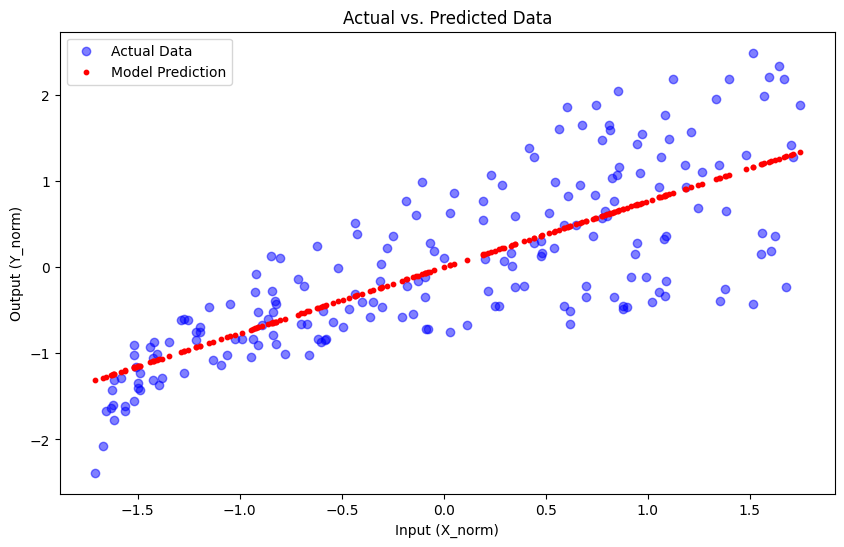

In [23]:
import matplotlib.pyplot as plt

# 1. GENERATE NEW PREDICTIONS USING YOUR TRAINED PARAMETERS!
# (If your trained weights are in 'parameters_simple', use that instead of 'parameters_test')
Y_hat_trained = forward_propagation(X_norm, parameters_test)

# 2. Flatten the NEW predictions for plotting
x_plot = X_norm.flatten()
y_true = Y_norm.flatten()
y_pred = Y_hat_trained.flatten() # <-- Use the new predictions here!

# 3. Plot the graph
plt.figure(figsize=(10, 6))
plt.scatter(x_plot, y_true, color='blue', alpha=0.5, label='Actual Data')
plt.scatter(x_plot, y_pred, color='red', s=10, label='Model Prediction')
plt.title("Actual vs. Predicted Data")
plt.xlabel("Input (X_norm)")
plt.ylabel("Output (Y_norm)")
plt.legend()
plt.show()

In [53]:
df = pd.read_csv('train.csv')
X_multi = df[['GrLivArea', 'OverallQual',]]
Y_multi = df['SalePrice']

In [54]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [55]:
display(X_multi)
display(Y_multi)

,GrLivArea,OverallQual
0,1710,7
1,1262,6
2,1786,7
3,1717,7
4,2198,8
...,...,...
1455,1647,6
1456,2073,6
1457,2340,7
1458,1078,5


0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64

In [56]:
X_multi_mean  = np.mean(X_multi , axis =0 )
X_multi_std = np.std(X_multi , axis =0 )
Y_multi_mean  = np.mean(Y_multi )
Y_multi_std = np.std(Y_multi)
X_multi_norm = (X_multi - X_multi_mean)/X_multi_std
Y_multi_norm = (Y_multi - Y_multi_mean)/Y_multi_std
print(np.sum(X_multi_norm))
print(np.sum(Y_multi_norm))

GrLivArea     -2.060574e-13
OverallQual    1.918465e-13
dtype: float64
1.9895196601282805e-13


C:\Users\User\AppData\Roaming\Python\Python313\site-packages\numpy\_core\fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [57]:
X_multi_norm = np.array(X_multi_norm).T
Y_multi_norm = np.array(Y_multi_norm).reshape((1, len(Y_multi_norm)))

print ('The shape of X: ' + str(X_multi_norm.shape))
print ('The shape of Y: ' + str(Y_multi_norm.shape))
print ('I have m = %d training examples!' % (X_multi_norm.shape[1]))

The shape of X: (2, 1460)
The shape of Y: (1, 1460)
I have m = 1460 training examples!


In [58]:
parameters_multi = nn_model(X_multi_norm, Y_multi_norm, learning_rate=0.01, num_iterations=1000, print_cost=True)

print("W = " + str(parameters_multi["W"]))
print("b = " + str(parameters_multi["b"]))

W_multi = parameters_multi["W"]
b_multi = parameters_multi["b"]

Cost after iteration 0 is : 0.5023696831263617 
Cost after iteration 1 is : 0.49108630470266906 
Cost after iteration 2 is : 0.4801589215820951 
Cost after iteration 3 is : 0.4695762871708517 
Cost after iteration 4 is : 0.45932751029761437 
Cost after iteration 5 is : 0.44940204398024236 
Cost after iteration 6 is : 0.43978967454754025 
Cost after iteration 7 is : 0.430480511104838 
Cost after iteration 8 is : 0.42146497533252303 
Cost after iteration 9 is : 0.41273379160700174 
Cost after iteration 10 is : 0.40427797743389854 
Cost after iteration 11 is : 0.39608883418362417 
Cost after iteration 12 is : 0.38815793811975724 
Cost after iteration 13 is : 0.3804771317109819 
Cost after iteration 14 is : 0.37303851521762393 
Cost after iteration 15 is : 0.36583443854410036 
Cost after iteration 16 is : 0.3588574933488831 
Cost after iteration 17 is : 0.35210050540383525 
Cost after iteration 18 is : 0.3455565271950381 
Cost after iteration 19 is : 0.3392188307574771 
Cost after iteratio

In [59]:
X_pred_multi = np.array([[1710, 7], [1200, 6], [2200, 8]]).T
Y_pred_multi = predict(X_multi, Y_multi, parameters_multi, X_pred_multi)

print(f"Ground living area, square feet:\n{X_pred_multi[0]}")
print(f"Rates of the overall quality of material and finish, 1-10:\n{X_pred_multi[1]}")
print(f"Predictions of sales price, $:\n{np.round(Y_pred_multi[0])}")

Ground living area, square feet:
[1710 1200 2200]
Rates of the overall quality of material and finish, 1-10:
[7 6 8]
Predictions of sales price, $:
[221341. 159972. 281588.]


In [40]:
y_hat =  forward_propagation(X_pred_multi,parameters_multi)
y_hat

array([[638.73786738, 448.85728584, 821.19451125]])

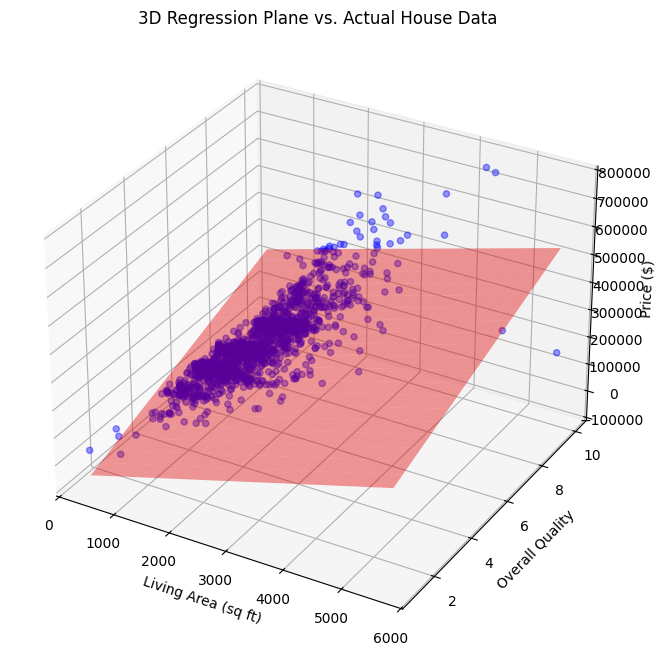

In [43]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Setup 3D Canvas
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 2. Plot the Actual Training Data (Unnormalized for real-world units)
ax.scatter(X_multi['GrLivArea'], X_multi['OverallQual'], Y_multi, color='blue', alpha=0.4, label='Actual Data')

# 3. Generate a grid of predictions to draw the regression plane
x_surf = np.linspace(X_multi['GrLivArea'].min(), X_multi['GrLivArea'].max(), 20)
y_surf = np.linspace(X_multi['OverallQual'].min(), X_multi['OverallQual'].max(), 20)
x_surf, y_surf = np.meshgrid(x_surf, y_surf)

# Format the grid points so our predict function can process them
surf_points = np.array([x_surf.flatten(), y_surf.flatten()])
# Predict and reshape back to the grid shape
z_surf = predict(X_multi, Y_multi, parameters_multi, surf_points).reshape(x_surf.shape)

# 4. Plot the Regression Plane
ax.plot_surface(x_surf, y_surf, z_surf, color='red', alpha=0.4, label='Regression Plane')

# Labels
ax.set_xlabel('Living Area (sq ft)')
ax.set_ylabel('Overall Quality')
ax.set_zlabel('Price ($)')
plt.title("3D Regression Plane vs. Actual House Data")
plt.show()

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive